# Модель для предсказания стоимости автомобиля

Выполнила: Тулянцева Альбина

Дата выполнения: 22.06.2026

**Описание проекта**: AutoValue AI — это амбициозный стартап, который внедряет модель мгновенного выкупа автомобилей на рынке подержанных автомобилей. Бизнес-модель простая, но рискованная: клиент заполняет анкету в приложении, алгоритм за одну секунду рассчитывает стоимость, если клиента устраивает цена, он приезжает в ближайший офис продаж, где техник за 15 минут подтверждает состояние авто, а клиент мгновенно получает деньги на счёт.

Раньше компания полагалась на штат из 50 экспертов-оценщиков. Они вручную мониторили площадки объявлений, смотрели аналоги и выносили вердикт. Но у этой системы есть «стеклянный потолок»: человеческий фактор, скорость, масштабируемость. AutoValue AI нужна модель, которая чувствует рынок. Цена на автомобиль — это не константа. Это сложный баланс между престижем марки автомобиля, реальным износом двигателя и психологией владения.

**Цель**: создать модель, которая будет автоматически назначать стоимость автомобилю.

**Задачи**:
1. Анализ данных
2. Предобработка данных
3. Обучение моделей в разных библиотеках
4. Работа с параметрами модели
5. Интерпретация и бизнес-анализ
6. Финальная проверка
7. Описание выводов

**Данные**:

brand - Марка автомобиля;

make_year - Год выпуска;

mileage_kmpl - Пробег (км);

engine_cc - Объём двигателя (в кубических см);

fuel_type - Тип топлива;

transmission - Тип коробки передач;

owner_count - Количество владельцев по ПТС;

color - Цвет автомобиля;

service_history - Наличие сервисной книжки;

accidents_reported - Количество зафиксированных ДТП;

insurance_valid - Действительна ли страховка;

region - Макрорегион РФ, в котором продаётся автомобиль (Москва, Сибирь, Юг);

**Целевая переменная**: price_rub - Целевой признак: рыночная стоимость автомобиля в рублях

**Постановка задачи машинного обучения**: 

Для эффективной работы модели нужно провести сравнительный анализ и выбрать одну из библиотек: CatBoost, XGBoost, LightGBM. Нужно проверить их на одних и тех же данных, подобрать лучшие гиперпараметры через библиотеку Optuna для каждой и собрать всё в одну таблицу для выявления лучшей точности.

Для сравнения библиотек будут использоваться следующие метрики: RMSE, MAE, R2, Overpricing rate (доля опасных переплат), Underpricing Loss (упущенная выгода). 

Далее нужно будет выяснить важность признаков через SHAP.

In [1]:
!pip install optuna phik shap -q
!pip install --upgrade xgboost -q

In [2]:
#Импорт библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import shap

#Импорт основных библиотек для моделей
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

#Импорт Optuna
import optuna
from optuna.samplers import TPESampler

#Импорт sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import plot_tree

#Импорт phik
from phik import phik_matrix

RANDOM_STATE=42

# **Часть 1. EDA (Экспресс-анализ данных)**

Проведите краткое исследование, чтобы лучше понимать данные.

**Задание 1.1:**

* Данные: загрузите `ds_s16_train_data.csv` (обучение) и `ds_s16_test_data.csv` (финальный тест). Обратите внимание на то, как прописать путь к данным: `/datasets/ds_s16_train_data.csv` и `/datasets/ds_s16_test_data.csv`
* Проведите краткий EDA: изучите распределение целевой переменной (`price_rub`), проверьте корреляции.

---

In [3]:
#Загрузка датасетов
train_df = pd.read_csv('/datasets/ds_s16_train_data.csv')
test_df = pd.read_csv('/datasets/ds_s16_test_data.csv')

print(f'Размер обучающей выборки: {train_df.shape}')
print(f'Размер тестовой выборки: {test_df.shape}')

Размер обучающей выборки: (8000, 13)
Размер тестовой выборки: (2000, 13)


In [4]:
#Общая информация об обучающей выборке
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   object 
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   object 
 6   transmission        8000 non-null   object 
 7   color               8000 non-null   object 
 8   service_history     8000 non-null   object 
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   object 
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 812.6+ KB


In [5]:
train_df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


In [6]:
train_df.describe()

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,price_rub
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8.000000e+03
mean,2009.221250,17.946343,2289.687500,3.001125,0.487875,6.836479e+05
std,8.388703,5.015565,1289.812139,1.419199,0.693839,2.649235e+05
min,1995.000000,5.000000,800.000000,1.000000,0.000000,9.500000e+04
25%,2002.000000,14.530000,1200.000000,2.000000,0.000000,4.938570e+05
50%,2009.000000,17.970000,2000.000000,3.000000,0.000000,6.638660e+05
75%,2017.000000,21.350000,3000.000000,4.000000,1.000000,8.550560e+05
max,2023.000000,35.000000,5000.000000,5.000000,5.000000,1.676525e+06


Первичный анализ обучающей выборки показывает, что в данных отсутствуют пропуски и все типы данных соответствуют. Все числовые признаки имеют нормальное распределение, без аномальных выбросов. Единственные выбросы присутствуют в столбце с информацией об объёме двигателя, однако никаких аномальных значений нет.

In [7]:
#Проверка тестовой выборки
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   object 
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   object 
 6   transmission        2000 non-null   object 
 7   color               2000 non-null   object 
 8   service_history     2000 non-null   object 
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   object 
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.2+ KB


In [8]:
test_df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


In [9]:
test_df.describe()

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,price_rub
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2.000000e+03
mean,2009.149500,18.018395,2276.900000,3.01300,0.509500,6.757919e+05
std,8.316052,5.065829,1297.392772,1.41804,0.695091,2.680196e+05
min,1995.000000,5.000000,800.000000,1.00000,0.000000,9.500000e+04
25%,2002.000000,14.570000,1200.000000,2.00000,0.000000,4.814770e+05
50%,2009.000000,18.005000,1800.000000,3.00000,0.000000,6.492840e+05
75%,2016.000000,21.382500,3000.000000,4.00000,1.000000,8.459695e+05
max,2023.000000,34.380000,5000.000000,5.00000,4.000000,1.629774e+06


В тестовой выборке также не содержатся пропуски, все типы данных соответствуют. Однако в тестовой выборке наблюдается больший разброс между медианой и средним значением в столбце с информацией об объёме двигателя, что говорит о выбросах в данных. Однако минимальное и максимальное значения являются вполне реальными, значит данные можно оставить в исходном состоянии.

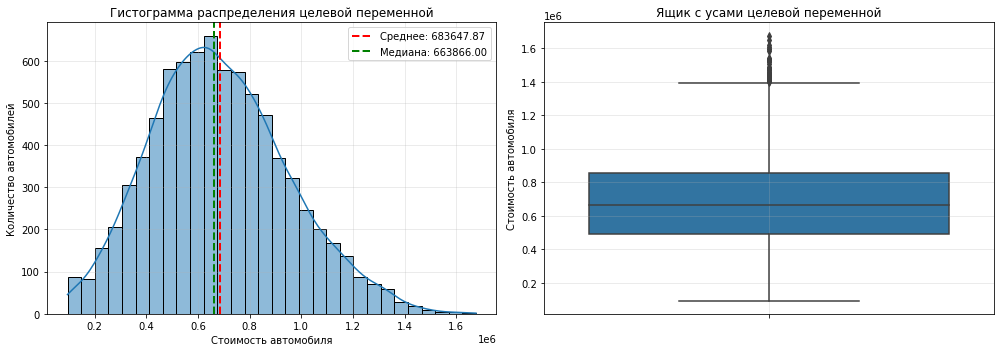

In [10]:
#Распределение целевой переменной
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
data = train_df['price_rub'].dropna()
mean_val = data.mean()
median_val = data.median()
    
#Гистограмма
sns.histplot(data, kde=True, bins=30, ax=ax1)
ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее: {mean_val:.2f}')
ax1.axvline(median_val, color='green', linestyle='--', linewidth=2, 
            label=f'Медиана: {median_val:.2f}')
    
ax1.set_title('Гистограмма распределения целевой переменной')
ax1.set_xlabel('Стоимость автомобиля')
ax1.set_ylabel('Количество автомобилей')
ax1.legend()
ax1.grid(True, alpha=0.3)

sns.boxplot(y=data, ax=ax2)
ax2.set_title('Ящик с усами целевой переменной')
ax2.set_ylabel('Стоимость автомобиля')
ax2.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()

Анализируя графики, можно заметить, что большинство автомобилей имеют рыночную стоимость 600-800 тыс рублей, что является средней стоимостью автомобилей по рынку. В данных есть небольшие выбросы в виде сильно маленьких значений (200 тыс руб), которые могут обуславливаться плохим качеством или старостью автомобиля. Также есть выбросы в виде высоко больших значений (1600000 руб), которые также не являются аномальными на рынке автомобилей. Таким образом, можно сказать, что целевая переменная имеет нормальное распределение со средним значением в районе 680 тыс руб.

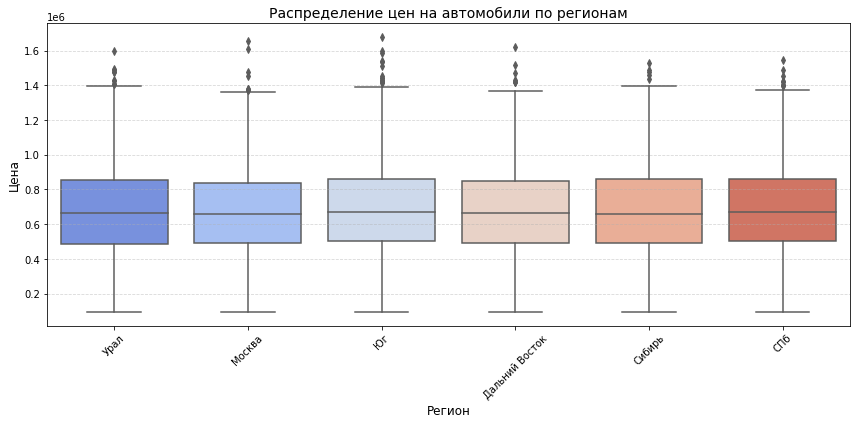

In [11]:
#Смотрим распределение цен в зависимости от региона
plt.figure(figsize=(12, 6))

#Строим boxplot
sns.boxplot(data=train_df, x='region', y='price_rub', palette='coolwarm')

plt.title('Распределение цен на автомобили по регионам', fontsize=14)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Цена', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

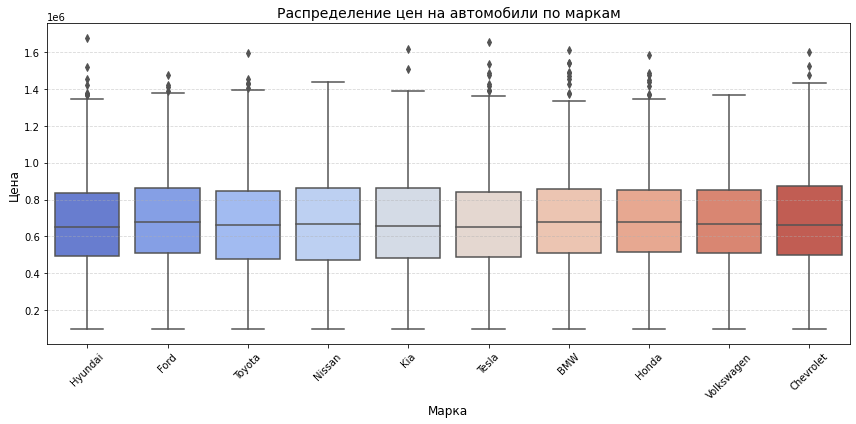

In [12]:
plt.figure(figsize=(12, 6))
#Смотрим распределение цен в зависимости от бренда
sns.boxplot(data=train_df, x='brand', y='price_rub', palette='coolwarm')

plt.title('Распределение цен на автомобили по маркам', fontsize=14)
plt.xlabel('Марка', fontsize=12)
plt.ylabel('Цена', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Распределение цен по регионам выглядит сбалансированым. Данные находятся примерно на одном уровне. Чуть более высокие аномалии наблюдаются на Юге и в Москве, однако это можно объяснить большим количеством автомобилей премиум-сегментов в этих регионах.

Распределение цен по маркам также является относительно сбалансированным. Выбросы наблюдаются только в марках, которые имеют модели более высокого качества, которые соответственно имеют стоимость выше, чем средний сегмент. Данные выбросы не являются аномалиями, а приходятся следствием того, что бренд выпускает автомобили для разных сегментов покупателей.

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable price_rub is large: 7929. Are you sure this is not an interval variable? Analysis for pairs of variables including price_rub can be slow.
  warnings.warn(


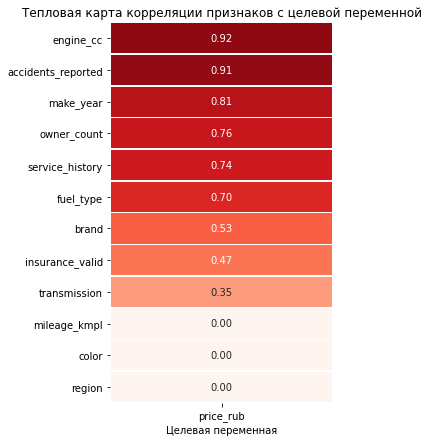

In [13]:
#Проверка корреляций
#Построим матрицу корреляции между признаками и целевой переменной
#Задаем интервальные столбцы
interval_cols = ['mileage_kmpl', 'engine_cc']
correlation_matrix = train_df[['make_year', 'mileage_kmpl', 'engine_cc', 
                         'fuel_type', 'owner_count', 'brand', 'transmission',
                        'color', 'service_history', 'accidents_reported', 'insurance_valid',
                        'region', 'price_rub']].phik_matrix(interval_cols=interval_cols)
#Строим тепловую карту
plt.figure(figsize=(4, 7))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'price_rub'][['price_rub']].sort_values(by='price_rub',
                                                                                                 ascending=False)

sns.heatmap(data_heatmap, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1, linewidths=0.5, cbar=False)

plt.title('Тепловая карта корреляции признаков с целевой переменной')
plt.xlabel('Целевая переменная')
plt.show()

Тепловая карта показывает наибольшую связь с целевой переменной у признака объёма двигателя. Это происходит потому, что объём двигателя показывает мощность автомобиля и является одним из главных критериев у покупателей. Также на целевую переменную сильно влияет количество зафиксированных ДТП, так как это говорит о нынешнем состоянии автомобиля и его возможных неисправностях. Третьим главным признаков выявляется год производства автомобиля, так как он показывает, насколько изношен автомобиль и как долго он еще может прослужить.

**Общий вывод после анализа данных**: Первичный анализ обучающей выборки показал, что в данных отсутствуют пропуски и все типы данных соответствуют. Все числовые признаки имеют нормальное распределение, без аномальных выбросов. Единственные выбросы присутствуют в столбце с информацией об объёме двигателя, однако никаких аномальных значений нет.

В тестовой выборке также не содержатся пропуски, все типы данных соответствуют. Однако в тестовой выборке наблюдается больший разброс между медианой и средним значением в столбце с информацией об объёме двигателя, что говорит о выбросах в данных. Однако минимальное и максимальное значения являются вполне реальными, значит данные можно оставить в исходном состоянии.

Анализируя графики, можно заметить, что большинство автомобилей имеют рыночную стоимость 600-800 тыс рублей, что является средней стоимостью автомобилей по рынку. В данных есть небольшие выбросы в виде сильно маленьких значений (200 тыс руб), которые могут обуславливаться плохим качеством или старостью автомобиля. Также есть выбросы в виде высоко больших значений (1600000 руб), которые также не являются аномальными на рынке автомобилей. Таким образом, можно сказать, что целевая переменная имеет нормальное распределение со средним значением в районе 680 тыс руб.

Распределение цен по регионам выглядит сбалансированым. Данные находятся примерно на одном уровне. Чуть более высокие аномалии наблюдаются на Юге и в Москве, однако это можно объяснить большим количеством автомобилей премиум-сегментов в этих регионах.

Распределение цен по маркам также является относительно сбалансированным. Выбросы наблюдаются только в марках, которые имеют модели более высокого качества, которые соответственно имеют стоимость выше, чем средний сегмент. Данные выбросы не являются аномалиями, а приходятся следствием того, что бренд выпускает автомобили для разных сегментов покупателей.

Тепловая карта показывает наибольшую связь с целевой переменной у признака объёма двигателя. Это происходит потому, что объём двигателя показывает мощность автомобиля и является одним из главных критериев у покупателей. Также на целевую переменную сильно влияет количество зафиксированных ДТП, так как это говорит о нынешнем состоянии автомобиля и его возможных неисправностях. Третьим главным признаков выявляется год производства автомобиля, так как он показывает, насколько изношен автомобиль и как долго он еще может прослужить.

# **Часть 2. Предобработка**

На этом этапе подготовьте данные для честного соревнования библиотек. Помните: качество входных данных определяет предел точности самого мощного алгоритма.

**Задание 2.1:**

* Создайте одинаковые обучающие и валидационные наборы данных для всех трех библиотек.
* Подготовьте признаки для каждой библиотеки.
* Зафиксируйте тест: используйте файл `ds_s16_test_data.csv` как отложенную тестовую выборку.

In [14]:
#Переводим object в category в обучающей выборке
cat_columns = ['fuel_type', 'brand', 'transmission', 'color', 
               'service_history', 'insurance_valid', 'region']
for col in cat_columns:
    train_df[col] = train_df[col].astype('category')
    
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   make_year           8000 non-null   int64   
 1   mileage_kmpl        8000 non-null   float64 
 2   engine_cc           8000 non-null   int64   
 3   fuel_type           8000 non-null   category
 4   owner_count         8000 non-null   int64   
 5   brand               8000 non-null   category
 6   transmission        8000 non-null   category
 7   color               8000 non-null   category
 8   service_history     8000 non-null   category
 9   accidents_reported  8000 non-null   int64   
 10  insurance_valid     8000 non-null   category
 11  price_rub           8000 non-null   int64   
 12  region              8000 non-null   category
dtypes: category(7), float64(1), int64(5)
memory usage: 431.1 KB


In [15]:
#Переводим object в category в тестовой выборке
for col in cat_columns:
    test_df[col] = test_df[col].astype('category')
    
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   make_year           2000 non-null   int64   
 1   mileage_kmpl        2000 non-null   float64 
 2   engine_cc           2000 non-null   int64   
 3   fuel_type           2000 non-null   category
 4   owner_count         2000 non-null   int64   
 5   brand               2000 non-null   category
 6   transmission        2000 non-null   category
 7   color               2000 non-null   category
 8   service_history     2000 non-null   category
 9   accidents_reported  2000 non-null   int64   
 10  insurance_valid     2000 non-null   category
 11  price_rub           2000 non-null   int64   
 12  region              2000 non-null   category
dtypes: category(7), float64(1), int64(5)
memory usage: 108.8 KB


In [16]:
#Определяем X и y для тестовой выборки
X_test = test_df.drop(columns=['price_rub'])
y_test = test_df['price_rub']

In [17]:
#Выделяем обучающую и валидационную выборки
X = train_df.drop(columns=['price_rub'])
y = train_df['price_rub']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер валидационной выборки: {X_val.shape}')

Размер обучающей выборки: (6400, 12)
Размер валидационной выборки: (1600, 12)


In [18]:
#Создаем признаки для XGBoost
X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()

if cat_columns:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_xgb[cat_columns] = encoder.fit_transform(X_train[cat_columns].astype(str))
    X_val_xgb[cat_columns] = encoder.transform(X_val[cat_columns].astype(str))


# **Часть 3. Обучение моделей в разных библиотеках**

Проверьте, как алгоритмы работают из коробки. Это покажет их естественную предрасположенность к вашему набору данных до начала тонкой настройки.

**Задание 3.1:**

* Обучите XGBoost, CatBoost и LightGBM на стандартных настройках.
* Установите для всех моделей `random_state=42`. В качестве целевой функции используйте MAE.
* Обучите каждую модель
* Задача со звёздочкой: замерьте время обучения и предсказания (Wall time) с помощью `%%time` или модуля `time`.

**Задание 3.2: Сравнение метрик**

* Рассчитайте математические метрики: MAE, RMSE, $R^2$.
* Рассчитайте бизнес-риски: Overpricing Rate (>20%) и Underpricing Loss (>20%).
* Сформулируйте гипотезу: какая библиотека на этом этапе кажется наиболее безопасной для бюджета компании?

**Задача со звёздочкой: модель с использованием Quantile Loss (квантильной регрессии) в CatBoost**

Что нужно сделать:

* Выберите библиотеку `CatBoost`. Реализуйте осторожную модель через квантильный лосс.
* Вместо стандартной функции потерь (MAE) установите `loss_function='Quantile'`.
* Настройте параметр квантиля. Достаточно при инициализации модели указать: `'Quantile:alpha=значение'`. Протестируйте разные значения, выберите оптимальное.
* Сравните результаты этой осторожной модели с базовой (обученной с помощью MAE):
  1. Насколько снизился Overpricing Rate?
  2. Насколько при этом вырос Underpricing Loss?
  3. Готовы ли вы рекомендовать такую безопасную модель Артёму (CEO) вместо самой точной базовой (обученной с помощью MAE)?

---

In [19]:
#Функция расчета метрик
def calculate_metrics(y_true, y_pred):
    
    error_ratio = (y_pred - y_true)/y_true
    
    #Доля опасных переплат
    overpricing_rate = (error_ratio > 0.20).mean()
    
    #Маска для случаев занижения цены на 20%+
    under_mask = error_ratio < -0.20
    
    #Упущенная выгода
    underpricing_loss = (y_true[under_mask] - y_pred[under_mask]).sum()
    
    #RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    #MAE
    mae = mean_absolute_error(y_true, y_pred)
    
    #R2
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
        "Overpricing Rate": round(overpricing_rate, 4),
        "Underpricing Loss": round(underpricing_loss, 4)
    }

In [20]:
results_list = []
#Обучим модель XGBoost
xgboost_model = XGBRegressor(objective='reg:absoluteerror', eval_metric='mae', random_state=RANDOM_STATE)

start_time = time.time()

xgboost_model.fit(X_train_xgb, y_train)
xgboost_train_time = time.time() - start_time

test_time = time.time()
y_pred_xgboost = xgboost_model.predict(X_val_xgb)

xgboost_test_time = time.time() - test_time

xgboost_metrics = calculate_metrics(y_val, y_pred_xgboost)

xgboost_metrics['Train Time (s)'] = xgboost_train_time
xgboost_metrics['Predict Time (s)'] = xgboost_test_time

xgboost_metrics['Model'] = 'XGBoost_general'

results_list.append(xgboost_metrics)

In [21]:
#Обучим LightGBM
lgbm_model = LGBMRegressor(objective='regression_l1', random_state=RANDOM_STATE)

start_time = time.time()

lgbm_model.fit(X_train, y_train,
              categorical_feature=cat_columns)

lgbm_train_time = time.time() - start_time

test_time = time.time()
y_pred_lgbm = lgbm_model.predict(X_val)

lgbm_test_time = time.time() - test_time

lgbm_metrics = calculate_metrics(y_val, y_pred_lgbm)

lgbm_metrics['Train Time (s)'] = lgbm_train_time
lgbm_metrics['Predict Time (s)'] = lgbm_test_time

lgbm_metrics['Model'] = 'LightGBM_general'

results_list.append(lgbm_metrics)

/opt/conda/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')


In [22]:
#Обучим CatBoost
catboost_model = CatBoostRegressor(loss_function='MAE', random_state=RANDOM_STATE)

start_time = time.time()

catboost_model.fit(
    X_train,
    y_train,
    cat_features=cat_columns,
    verbose=500
)

catboost_train_time = time.time() - start_time
test_time = time.time()

y_pred_catboost = catboost_model.predict(X_val)

catboost_test_time = time.time() - test_time

catboost_metrics = calculate_metrics(y_val, y_pred_catboost)

catboost_metrics['Train Time (s)'] = catboost_train_time
catboost_metrics['Predict Time (s)'] = catboost_test_time

catboost_metrics['Model'] = 'CatBoost_general'

results_list.append(catboost_metrics)

0:	learn: 208483.8811081	total: 58.6ms	remaining: 58.5s
500:	learn: 70038.0098020	total: 3.54s	remaining: 3.52s
999:	learn: 67118.1737524	total: 6.67s	remaining: 0us


In [23]:
#Обучим CatBoost
catboost_model = CatBoostRegressor(loss_function='Quantile:alpha=0.2', random_state=42)

start_time = time.time()

catboost_model.fit(
    X_train,
    y_train,
    cat_features=cat_columns,
    verbose=500
)

catboost_train_time = time.time() - start_time
test_time = time.time()

y_pred_catboost = catboost_model.predict(X_val)

catboost_test_time = time.time() - test_time

catboost_metrics = calculate_metrics(y_val, y_pred_catboost)

catboost_metrics['Train Time (s)'] = catboost_train_time
catboost_metrics['Predict Time (s)'] = catboost_test_time

catboost_metrics['Model'] = 'CatBoost_alpha0.2'

results_list.append(catboost_metrics)

0:	learn: 69055.9970470	total: 10.6ms	remaining: 10.6s
500:	learn: 24632.6941927	total: 3.42s	remaining: 3.41s
999:	learn: 23743.2672145	total: 6.5s	remaining: 0us


In [24]:
#Обучим CatBoost
catboost_model = CatBoostRegressor(loss_function='Quantile:alpha=0.8', random_state=42)

start_time = time.time()

catboost_model.fit(
    X_train,
    y_train,
    cat_features=cat_columns,
    verbose=500
)

catboost_train_time = time.time() - start_time
test_time = time.time()

y_pred_catboost = catboost_model.predict(X_val)

catboost_test_time = time.time() - test_time

catboost_metrics = calculate_metrics(y_val, y_pred_catboost)

catboost_metrics['Train Time (s)'] = catboost_train_time
catboost_metrics['Predict Time (s)'] = catboost_test_time

catboost_metrics['Model'] = 'CatBoost_alpha0.8'

results_list.append(catboost_metrics)

0:	learn: 76973.4746468	total: 10.3ms	remaining: 10.3s
500:	learn: 24517.0549361	total: 3.56s	remaining: 3.55s
999:	learn: 23552.0429850	total: 6.68s	remaining: 0us


In [25]:
all_results_df = pd.DataFrame(results_list)
comparison_table = all_results_df.groupby('Model').mean()

display(comparison_table.sort_values(by='MAE'))

,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (s),Predict Time (s)
Model,,,,,,,
CatBoost_general,79367.4913,99047.1770,0.8551,0.1338,1.669954e+07,8.350355,0.006291
LightGBM_general,82358.3619,102842.2717,0.8438,0.1388,1.933291e+07,1.169260,0.011003
XGBoost_general,86800.0029,108365.0108,0.8266,0.1456,2.520976e+07,0.203671,0.007740
CatBoost_alpha0.8,97426.9779,121139.4062,0.7833,0.3012,1.339443e+06,8.384261,0.006459
CatBoost_alpha0.2,103258.8455,126622.3762,0.7633,0.0506,8.109930e+07,7.916920,0.005528


Наиболее безопасной библиотекой на данном этапе кажется CatBoost с базовыми настройками. Она в среднем допускает ошибку лишь в 79367 руб и правильно предсказывает около 85% данных. Модель имеет одно из лучших значений по доле опасных переплат. Используя эту модель, лишь в 13% случаев компания рискует купить автомобиль, который тяжело будет продать, так как цена для изначального продавца была на 20% выше среднерыночной. Также Catboost с базовыми настройками предполагает, что в среднем компания теряет около 16 699 540 руб, так как модель предлагает слишком низкую цену за автомобиль, и покупатель уходит к конкурентам.

Если изменять квантиль со стандартного 0.5 у библиотеки CatBoost, то можно увидеть следующие изменения. При изменении квантиля до 0.2 модель штрафует сильнее за переплаты. Это можно увидеть и по метрикам, доля опасных переплат падает до 0,5%, однако очень сильно возрастает показатель упущенной выгоды, до 81 099 300 рублей. То есть, компания очень сильно перестраховывается, за счет чего теряет потенциальных клиентов. Однако, при изменении квантиля до 0.8 модель больше штрафует за недоплату, что максимально снижает упущенную выгоду до 1 339 443 рублей, ведь модель старается максимально предложить цену выше среднерыночной. Однако, таким образом очень сильно повышается доля опасных переплат, до 30%. Таким образом, для сохранения баланса между упущенной выгоды и опасной переплатой, я бы предложила оставить базовый квантиль 0.5.

# **Часть 4. Работа с параметрами модели (Тюнинг)**

Теперь ваша задача — заставить алгоритмы работать на пределе возможностей, подбирая ключи к их гиперпараметрам. Чтобы сравнение было объективным, используйте единую стратегию поиска для всех библиотек.

**Задание 4.1:**

* Настройте поиск в Optuna для каждой модели.
* Использьзуйте сетку параметров, предложенную в описании проекта:
  1. **Общая сетка для всех моделей:**
    * Скорость обучения (`learning_rate/eta`): от `0.01` до `0.1, log=True`.
    * Глубина дерева (`max_depth/depth`): от `3` до `10`.
    * Количество итераций (`n_estimators/iterations`): зафиксируйте в диапазоне `500–2000`.
  2. **Специфические параметры (регуляризация):**
  * Для XGBoost: добавьте параметры `gamma` (от `1e-8` до `1.0`) и `reg_lambda/reg_alpha`(от `1e-8` до `10.0`).
  * Для CatBoost: используйте `l2_leaf_reg` (от `1` до `10`).
  * Для LightGBM: добавьте `num_leaves` (от `20` до `256`) и `min_child_samples` (от `5` до `100`); `reg_alpha` и `reg_lambda` от `1e-8` до `1.0`.
  3. Не забудьте `"random_seed": 42` и `MAE` .

* Проведите поиск гиперпараметров с помощью Optuna.
---


In [26]:
#XGBoost с Optuna
def xgboostobjective(trial):
    
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0)
    }
    model = XGBRegressor(**params, random_state=RANDOM_STATE, objective='reg:absoluteerror', eval_metric='mae')
    
    model.fit(X_train_xgb, y_train,
             verbose=False)
    y_pred = model.predict(X_val_xgb)
    
    score = mean_absolute_error(y_val, y_pred)
    
    return score

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_xgb = optuna.create_study(direction='minimize')

study_xgb.optimize(xgboostobjective, n_trials=50)

print("Лучшие параметры:", study_xgb.best_params)
print("Лучший результат MAE на валидации:", study_xgb.best_value)

Лучшие параметры: {'learning_rate': 0.030071820962304197, 'max_depth': 3, 'n_estimators': 713, 'gamma': 0.1759135687880194, 'reg_lambda': 0.12875968580419242}
Лучший результат MAE на валидации: 80285.59603515625


In [27]:
#Считаем все метрики
best_params_xgb = study_xgb.best_params

xgboost_optuna_model = XGBRegressor(
    **best_params_xgb,
    random_state=RANDOM_STATE,
    objective='reg:absoluteerror',
    eval_metric='mae'
)

start_time = time.time()
xgboost_optuna_model.fit(
    X_train_xgb, y_train,
    verbose=False
)
xgb_optuna_train_time = time.time() - start_time

test_time = time.time()
y_pred_xgb_optuna = xgboost_optuna_model.predict(X_val_xgb)
xgb_optuna_test_time = time.time() - test_time

xgb_optuna_metrics = calculate_metrics(y_val, y_pred_xgb_optuna)

xgb_optuna_metrics['Train Time (s)'] = xgb_optuna_train_time
xgb_optuna_metrics['Predict Time (s)'] = xgb_optuna_test_time
xgb_optuna_metrics['Model'] = 'XGBoost_Optuna'

results_list.append(xgb_optuna_metrics)

In [28]:
#LightGBM с Optuna
def lightgbmobjective(trial):
    
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0)
    }
    model = LGBMRegressor(**params, random_state=RANDOM_STATE, objective='regression_l1', verbose=-1)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    score = mean_absolute_error(y_val, y_pred)
    
    return score

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lgbm = optuna.create_study(direction='minimize')

study_lgbm.optimize(lightgbmobjective, n_trials=50)

print("Лучшие параметры:", study_lgbm.best_params)
print("Лучший результат MAE на валидации:", study_lgbm.best_value)

Лучшие параметры: {'learning_rate': 0.024671831129484855, 'max_depth': 3, 'n_estimators': 873, 'num_leaves': 220, 'min_child_samples': 19, 'reg_alpha': 0.001729541858390915, 'reg_lambda': 0.40939961905104194}
Лучший результат MAE на валидации: 80039.89978029189


In [29]:
#Считаем все метрики
best_params_lgbm = study_lgbm.best_params

lightgbm_optuna_model = LGBMRegressor(
    **best_params_lgbm,
    random_state=RANDOM_STATE,
    objective='regression_l1', verbose=-1
)

start_time = time.time()
lightgbm_optuna_model.fit(
    X_train, y_train)
lgbm_optuna_train_time = time.time() - start_time

test_time = time.time()
y_pred_lgbm_optuna = lightgbm_optuna_model.predict(X_val)
lgbm_optuna_test_time = time.time() - test_time

lgbm_optuna_metrics = calculate_metrics(y_val, y_pred_lgbm_optuna)

lgbm_optuna_metrics['Train Time (s)'] = lgbm_optuna_train_time
lgbm_optuna_metrics['Predict Time (s)'] = lgbm_optuna_test_time
lgbm_optuna_metrics['Model'] = 'LightGBM_Optuna'

results_list.append(lgbm_optuna_metrics)

In [30]:
#CatBoost с Optuna
def catboostobjective(trial):
    
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10)
    }
    model = CatBoostRegressor(**params, random_state=RANDOM_STATE, loss_function='MAE')
    
    model.fit(X_train, y_train, cat_features=cat_columns,
    verbose=False)
    y_pred = model.predict(X_val)
    
    score = mean_absolute_error(y_val, y_pred)
    
    return score

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_catboost = optuna.create_study(direction='minimize')

study_catboost.optimize(catboostobjective, n_trials=50)

print("Лучшие параметры:", study_catboost.best_params)
print("Лучший результат MAE на валидации:", study_catboost.best_value)

Лучшие параметры: {'learning_rate': 0.030420090651153937, 'max_depth': 3, 'n_estimators': 1360, 'l2_leaf_reg': 1}
Лучший результат MAE на валидации: 79236.4865350283


In [31]:
#Считаем все метрики
best_params_catboost = study_catboost.best_params

catboost_optuna_model = CatBoostRegressor(
    **best_params_catboost,
    random_state=RANDOM_STATE,
    loss_function='MAE'
)

start_time = time.time()
catboost_optuna_model.fit(
    X_train, y_train, cat_features=cat_columns, verbose=False)
catboost_optuna_train_time = time.time() - start_time

test_time = time.time()
y_pred_catboost_optuna = catboost_optuna_model.predict(X_val)
catboost_optuna_test_time = time.time() - test_time

catboost_optuna_metrics = calculate_metrics(y_val, y_pred_catboost_optuna)

catboost_optuna_metrics['Train Time (s)'] = catboost_optuna_train_time
catboost_optuna_metrics['Predict Time (s)'] = catboost_optuna_test_time
catboost_optuna_metrics['Model'] = 'CatBoost_Optuna'

results_list.append(catboost_optuna_metrics)

In [32]:
all_results_df = pd.DataFrame(results_list)
comparison_table = all_results_df.groupby('Model').mean()

display(comparison_table.sort_values(by='MAE'))

,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (s),Predict Time (s)
Model,,,,,,,
CatBoost_Optuna,79236.4865,98768.7032,0.8560,0.1344,1.661593e+07,9.944902,0.004989
CatBoost_general,79367.4913,99047.1770,0.8551,0.1338,1.669954e+07,8.350355,0.006291
LightGBM_Optuna,80039.8998,100555.3100,0.8507,0.1356,1.907349e+07,2.998610,0.190943
XGBoost_Optuna,80285.5960,100669.8131,0.8504,0.1362,1.862775e+07,1.086496,0.012947
LightGBM_general,82358.3619,102842.2717,0.8438,0.1388,1.933291e+07,1.169260,0.011003
XGBoost_general,86800.0029,108365.0108,0.8266,0.1456,2.520976e+07,0.203671,0.007740
CatBoost_alpha0.8,97426.9779,121139.4062,0.7833,0.3012,1.339443e+06,8.384261,0.006459
CatBoost_alpha0.2,103258.8455,126622.3762,0.7633,0.0506,8.109930e+07,7.916920,0.005528


После подбора гиперпараметров можно сказать, что лучшей библиотекой оказалась CatBoost с гиперпараметрам 'learning_rate': 0.030420090651153937, 'max_depth': 3, 'n_estimators': 1360, 'l2_leaf_reg': 1. Её средняя ошибка составляет 79236 рублей, что является самым низким показателем среди моделей. Так как средние значения целевой переменной находятся в районе 683 647 рублей, то средняя ошибка в 79236 рублей говорит о хорошей работе модели. Модель верно предсказывает 85% данных, что также говорит в ее пользу. Доля опасных переплат составляет 13%, что является одним из самых низких показателей. Доля упущенной выгоды у этой модели составляет 16 615 930 рублей. В среднем модель обучается 9,9 секунд и делает предсказания в течение 0,004 секунд, а значит клиенту не придется долго ждать ответа от системы, что не позволит ему уйти к конкурентам. Таким образом, данная модель является идеальным балансом между всеми метриками, что дает право использовать ее на тестовой выборке для проверки ее стабильности.

# **Часть 5. Интерпретация и бизнес-анализ**

Модель должна быть прозрачной. Ваша задача — убедиться, что алгоритм принимает решения на основе рыночных факторов, а не случайных корреляций.

**Задание 5.1:**

* Постройте SHAP Summary Plot для оптимизированных моделей после поиска Optuna.
* Проанализируйте:
  1. Какие Топ-5 признаков вносят наибольший вклад в цену автомобиля?
  2. Совпадают ли выводы модели с бизнес-логикой?
  3. Как специфические признаки (например, color или insurance_valid) влияют на предсказание?

**Задание 5.2**

Используйте введённые метрики Overpricing Rate и Underpricing Loss:
* Рассчитайте долю завышений и недооценок для каждой модели.
* Сравните модели не только по MAE и RMSE, но и по бизнес-рискам.

**Задание 5.3**

* Проанализируйте ошибки в разрезе категорий (марки автомобилей и макро-регионов).
* Выявите марки машин и регионы, где риск ошибки высок — это зоны, где в будущем потребуется ручная проверка экспертом.

---

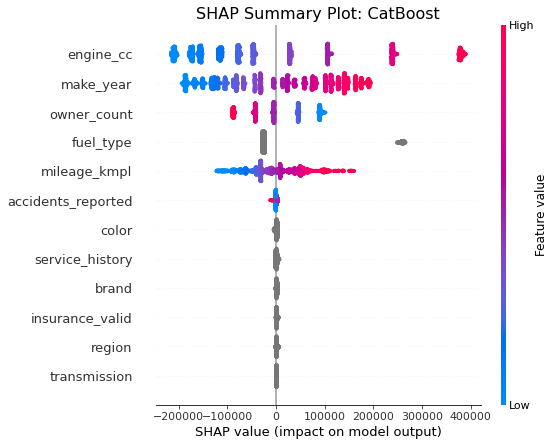

In [33]:
#Строим SHAP Summary plot
explainer = shap.TreeExplainer(catboost_optuna_model)
shap_values = explainer.shap_values(X_val)

# Summary Plot для всех признаков
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("SHAP Summary Plot: CatBoost", fontsize=16)
plt.tight_layout()
plt.show()

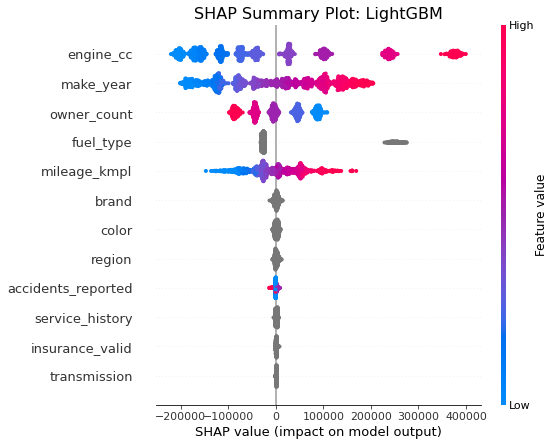

In [34]:
#Строим SHAP Summary plot
explainer = shap.TreeExplainer(lightgbm_optuna_model)
shap_values = explainer.shap_values(X_val)

# Summary Plot для всех признаков
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("SHAP Summary Plot: LightGBM", fontsize=16)
plt.tight_layout()
plt.show()

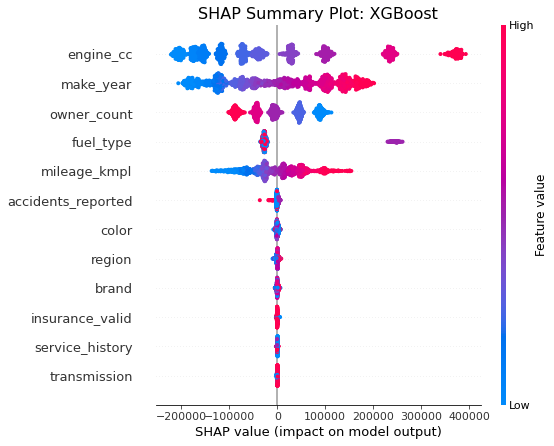

In [35]:
#Строим SHAP Summary plot
explainer = shap.TreeExplainer(xgboost_optuna_model)
shap_values = explainer.shap_values(X_val_xgb)

# Summary Plot для всех признаков
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_xgb, show=False)
plt.title("SHAP Summary Plot: XGBoost", fontsize=16)
plt.tight_layout()
plt.show()

Топ-5 самыми важными признаками для моделей стали объём двигателя, год выпуска, количество владельцев, пробег и количество ДТП автомобиля. Данные признаки напрямую влияют на состоянии и износ автомобиля, поэтому модели считают их самыми важными в своем предсказании. Чем больше объём двигателя, тем выше цена автомобиля, так как большой объём двигателя присущ крупным машинам. Год выпуска также имеет прямую связь с ценой, так как более новая машина будет в более качественном состоянии, соответственно с более высокой ценой. Количество владельцев обратно влияет на цену, так как переоформление машины с большим количеством влидельцев юридически затратнее, что мешает ее спокойной перепродаже. Интересным замечанием модели является то, что пробег напрямую влияет на стоимость, хотя в реальной жизни высокий пробег означает большой износ автомобиля, что должно снижать стоимость автомобиля. Количество ДТП снижает стоимость автомобиля.

In [36]:
#Анализ ошибок в разрезе категорий у лучшей модели CatBoost
analysis_df = X_val.copy()

#Добавляем таргет и предсказания
analysis_df['true_price'] = y_val
analysis_df['pred_price'] = y_pred_catboost_optuna

#Считаем абсолютную ошибку в деньгах
analysis_df['abs_error'] = (analysis_df['true_price'] - analysis_df['pred_price']).abs()

#Считаем ошибку в процентах
analysis_df['percentage_error'] = (analysis_df['abs_error'] / analysis_df['true_price']) * 100

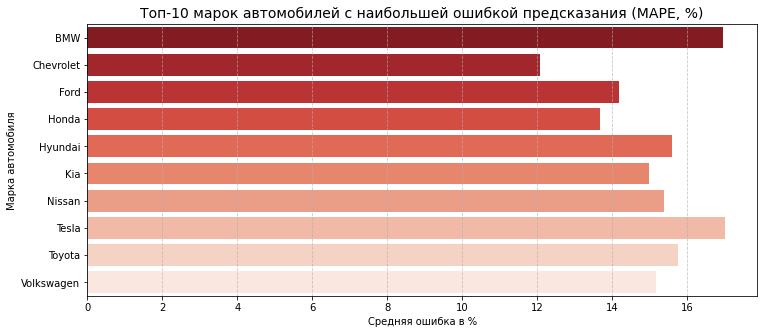

Топ проблемных марок:


,brand,Mean_MAE,Mean_MAPE,Car_Count
1,Chevrolet,72327.034670,12.069160,159
3,Honda,71238.214675,13.677377,132
2,Ford,76824.107563,14.188201,147
5,Kia,83634.360695,14.983726,167
9,Volkswagen,75872.657978,15.166976,173
6,Nissan,75533.429085,15.386847,170
4,Hyundai,77898.519193,15.598381,166
8,Toyota,85266.055345,15.768440,152
0,BMW,86554.682191,16.961078,171
7,Tesla,85618.132091,17.018973,163


In [37]:
#Группируем по маркам
brand_analysis = analysis_df.groupby('brand').agg(
    Mean_MAE=('abs_error', 'mean'),
    Mean_MAPE=('percentage_error', 'mean'),
    Car_Count=('abs_error', 'count')
).reset_index()

#Фильтруем, оставляем только те марки, которых в валидации хотя бы > 10 штук
min_cars = 10 
popular_brand_errors = brand_analysis[brand_analysis['Car_Count'] >= min_cars]

#Сортируем по убыванию процентной ошибки и берем Топ-10 проблемных
top_error_brands = popular_brand_errors.sort_values(by='Mean_MAPE', ascending=False).head(10)

#Визуализация
plt.figure(figsize=(12, 5))
sns.barplot(data=top_error_brands, x='Mean_MAPE', y='brand', palette='Reds_r')
plt.title('Топ-10 марок автомобилей с наибольшей ошибкой предсказания (MAPE, %)', fontsize=14)
plt.xlabel('Средняя ошибка в %')
plt.ylabel('Марка автомобиля')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Топ проблемных марок:")
display(top_error_brands.sort_values(by='Mean_MAPE'))

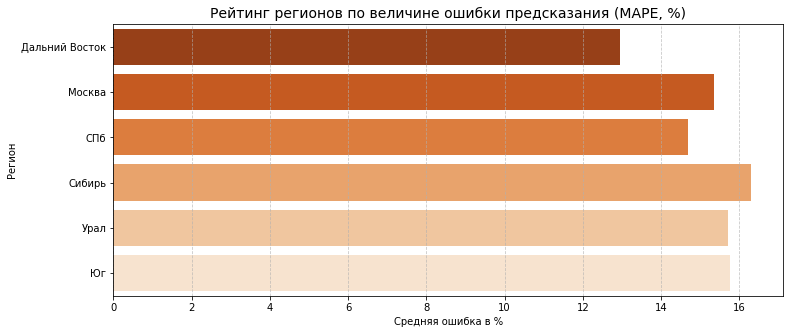

Рейтинг регионов по ошибкам:


,region,Mean_MAE,Mean_MAPE,Car_Count
0,Дальний Восток,80619.718485,12.939696,262
2,СПб,78758.830714,14.677662,267
1,Москва,76427.137485,15.356516,249
4,Урал,82364.454766,15.713464,276
5,Юг,76468.098031,15.764428,293
3,Сибирь,80866.817945,16.299517,253


In [38]:
#Группируем по регионам
region_analysis = analysis_df.groupby('region').agg(
    Mean_MAE=('abs_error', 'mean'),
    Mean_MAPE=('percentage_error', 'mean'),
    Car_Count=('abs_error', 'count')
).reset_index()

#Сортируем по убыванию ошибки
top_error_regions = region_analysis.sort_values(by='Mean_MAPE', ascending=False)

#Визуализация
plt.figure(figsize=(12, 5))
sns.barplot(data=top_error_regions, x='Mean_MAPE', y='region', palette='Oranges_r')
plt.title('Рейтинг регионов по величине ошибки предсказания (MAPE, %)', fontsize=14)
plt.xlabel('Средняя ошибка в %')
plt.ylabel('Регион')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Рейтинг регионов по ошибкам:")
display(top_error_regions.sort_values(by='Mean_MAPE'))

Анализ показывает, что модель чаще всего ошибается в стоимости автомобилей марок Tesla, BMW и Toyota. Большая ошибка у этих марок скорее всего происходит из-за большого разнообразия моделей и сильной зависимости от наполнения конкретного автомобиля. У данных моделей разница между конкретными моделями может превышать более 5 млн рублей. Для правильного прогнозирования цены этих автомобилей можно ввести ручную проверку в будущем.

Если смотреть ошибки в разрезе регионов, то хуже всего модель предсказывает стоимости автомобилей из Сибири, Юга и Урала. Это можно объяснить тем, что у данных регионов существуют особенные специфики важные для формирования цены. В Сибири важны функции автономного прогрева и, возможно, дополнительные комплекты резины. На Урале существуют проблемы с дорогами, а также суровые зимы, которые изнашивают автомобили быстрее. На Юге важны светлые цвета, чтобы машина меньше нагревалась, а сами машины меньше изнашиваются и могут иметь более высокую цену. Таким образом, для таких регионов тоже нужна ручная проверка.

# **Часть 6. Финальная проверка**

Момент истины. На этом этапе вы должны подтвердить надежность выбранного решения на данных, которые модель никогда не видела, и дать обоснованную рекомендацию бизнесу.

**Задание 6.1**

* Выберите лучшую модель и прогоните её через `ds_s16_test_data.csv`.
* Сформируйте итоговый результат на тестовой выборке. Проверьте, нет ли переобучения.

In [39]:
#Проверка на тестовой выборке
test_start_time = time.time()
y_pred_test = catboost_optuna_model.predict(X_test)
test_predict_time = time.time() - test_start_time

metrics_test = calculate_metrics(y_test, y_pred_test)
metrics_test['Train Time (s)'] = catboost_optuna_train_time
metrics_test['Predict Time (s)'] = test_predict_time
metrics_test['Model'] = 'CatBoost_Optuna'
catboost_optuna_metrics['Data Split'] = 'Validation'
metrics_test['Data Split'] = 'Test'

catboost_comparison_df = pd.DataFrame([catboost_optuna_metrics, metrics_test])

catboost_comparison_df.set_index(['Model', 'Data Split'], inplace=True)

print("Сравнение результатов CatBoost на валидации и тесте:")
display(catboost_comparison_df)

Сравнение результатов CatBoost на валидации и тесте:


MAE        RMSE      R2  Overpricing Rate  \
Model           Data Split                                                     
CatBoost_Optuna Validation  79236.4865  98768.7032  0.8560            0.1344   
                Test        75705.1261  94848.3509  0.8747            0.1335   

                            Underpricing Loss  Train Time (s)  \
Model           Data Split                                      
CatBoost_Optuna Validation       1.661593e+07        9.944902   
                Test             1.975022e+07        9.944902   

                            Predict Time (s)  
Model           Data Split                    
CatBoost_Optuna Validation          0.004989  
                Test                0.006973

Проверка на тестовой выборке показывает, что модель сохраняет свою стабильность. Средняя ошибка на тестовой выборке составляет 75 705 рублей, что ещё меньше, чем на валидационной выборке. В среднем модель предсказывает около 87% данных, что является очень хороим показателем. Доля опасных переплат на тестовой выборке составляет всего 13%, а упущенная выгода равна 19 750 220 рублей. Таким образом, модель сохраняет баланс между переплатой и недоплатой за автомобиль, имеет среднюю ошибку около 11% от среднего значения целевой переменной и правильно предсказывает почти все данные. Всё вышеперечисленное указывает на то, что модель можно рекомендовать в продакшен.

 # **Часть 7. Описание выводов и финальный вердикт**

**Задание 7.1**

Заполните краткую аналитическую записку на основе ваших данных.

**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

1. Рекомендованная модель: [Название вашей лучшей модели, например]

2. Точность оценки: в среднем модель ошибается на [Ваше MAE] руб. Коэффициент детерминации равен[Ваше $R^2$], что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне [Ваш %]. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до [Сумма Underpricing Loss] руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе [Ваш проблемный регион] и на марках [Ваши проблемные марки].

6. Какие гиперпараметры следует зафиксировать для интеграции в мобильное приложение.

---

1. Рекомендованная к продакшену модель: catboost_optuna_model
2. В среднем модель ошибается 75 705 рублей. Коэффициент детерминации равен 0.87, что подтверждает высокую надёжность прогнозов.
3. Риск опасной переплаты (Overpriving rate > 20%) зафиксирован на уровне 13%. Это позволяет стартапу сохранять маржинальность при выкупе и не тратить ограниченный бюджет на покупку переоцененных автомобилей.
4. Компания может терять до 19 750 220 рублей в месяц из-за занижения цены. Для автомобилей премиум-сегмента рекомендуется ручной пересмотр. 
5. Для автомбилей марок Tesla, BMW, Toyota и Сибирского, Уральского и Южного ФО рекомендуется ручной пересмотр цен, так как модель часто ошибается именно в этих зонах.
6. Если для бизнеса важно сократить упущенную выгоду, то при построении модели CatBoost можно повысить квантиль. Если в данный момент для бизнеса важнее сократить долю опасных переплат, то квантиль стоит понизить. Однако, для сохранения баланса рекомендуется сохранять базовый квантиль 0.5.
7. Гиперпараметры рекомендованной модели: 'learning_rate': 0.030420090651153937, 'max_depth': 3, 'n_estimators': 1360, 'l2_leaf_reg': 1.